In [1]:
import os
path = os.getenv('DATA_PATH')
token = os.getenv('API_TOKEN')

In [2]:
from a3em_analysis.datasets import Arden
arden = Arden(path, token)
X_train, X_test, y_train, y_test = arden.load_data_ml(random_state=123, shuffle=True) 

prefetch complete
extracting features


100%|██████████| 62/62 [01:55<00:00,  1.87s/it]


In [3]:
X_train.head()

,peak_freq,centroid,bandwidth,freq_5,freq_95,hnr,hnr_low,mfcc_1,mfcc_2,mfcc_3,...,mel_mean_17,mel_mean_18,mel_mean_19,mel_mean_20,mel_mean_21,mel_mean_22,mel_mean_23,mel_mean_24,mel_mean_25,mel_mean_26
384,23.437500,111.260302,90.533076,23.437500,127.929688,7.358960,8.113923,-243.844849,239.469313,25.758786,...,0.000786,0.000513,0.000320,0.000184,0.000073,0.000032,0.000019,0.000003,6.908599e-07,6.537715e-08
1873,33.203125,192.228073,137.069654,33.203125,249.023438,-10.580088,-1.501752,-220.564623,198.817946,-24.868339,...,0.016844,0.014855,0.005126,0.002918,0.001306,0.000712,0.000435,0.000155,6.213578e-05,3.059433e-05
1836,22.460938,106.192751,91.614200,22.460938,124.023438,6.556033,9.614664,-270.421934,224.399037,37.934304,...,0.000728,0.000332,0.000276,0.000182,0.000130,0.000099,0.000079,0.000070,6.746972e-05,6.608961e-05
1134,26.367188,156.298342,119.247841,18.554688,213.867188,-28.401458,-27.710959,-485.889764,114.312443,25.904153,...,0.000430,0.000360,0.000284,0.000244,0.000223,0.000213,0.000203,0.000197,1.917877e-04,1.898079e-04
666,31.250000,84.157725,92.847806,16.601562,87.890625,-6.149483,-5.686040,-300.628904,215.776552,38.748467,...,0.000366,0.000285,0.000201,0.000176,0.000153,0.000132,0.000120,0.000114,1.121545e-04,1.105504e-04


In [4]:
y_train.head()

384     0
1873    0
1836    1
1134    0
666     0
Name: label, dtype: int64

## Analysis

In [5]:
import pandas as pd

In [6]:
train_features = X_train
test_feature = X_test
train_labels = y_train
test_labels = y_test

features_aggregate = pd.concat([train_features, test_feature], ignore_index=True)
labels_aggregate = pd.concat([train_labels, test_labels], ignore_index=True)

In [7]:
labels_aggregate.value_counts()

label
0    1187
1     705
Name: count, dtype: int64

In [8]:
# Combine
df = train_features.copy()
df['label'] = train_labels

In [9]:
df.head()

,peak_freq,centroid,bandwidth,freq_5,freq_95,hnr,hnr_low,mfcc_1,mfcc_2,mfcc_3,...,mel_mean_18,mel_mean_19,mel_mean_20,mel_mean_21,mel_mean_22,mel_mean_23,mel_mean_24,mel_mean_25,mel_mean_26,label
384,23.437500,111.260302,90.533076,23.437500,127.929688,7.358960,8.113923,-243.844849,239.469313,25.758786,...,0.000513,0.000320,0.000184,0.000073,0.000032,0.000019,0.000003,6.908599e-07,6.537715e-08,0
1873,33.203125,192.228073,137.069654,33.203125,249.023438,-10.580088,-1.501752,-220.564623,198.817946,-24.868339,...,0.014855,0.005126,0.002918,0.001306,0.000712,0.000435,0.000155,6.213578e-05,3.059433e-05,0
1836,22.460938,106.192751,91.614200,22.460938,124.023438,6.556033,9.614664,-270.421934,224.399037,37.934304,...,0.000332,0.000276,0.000182,0.000130,0.000099,0.000079,0.000070,6.746972e-05,6.608961e-05,1
1134,26.367188,156.298342,119.247841,18.554688,213.867188,-28.401458,-27.710959,-485.889764,114.312443,25.904153,...,0.000360,0.000284,0.000244,0.000223,0.000213,0.000203,0.000197,1.917877e-04,1.898079e-04,0
666,31.250000,84.157725,92.847806,16.601562,87.890625,-6.149483,-5.686040,-300.628904,215.776552,38.748467,...,0.000285,0.000201,0.000176,0.000153,0.000132,0.000120,0.000114,1.121545e-04,1.105504e-04,0


### Compute Summary Statistics

In [10]:
summary = df.groupby("label").mean()

std_summary = df.groupby("label").std()

comparison = pd.DataFrame({
    "Background Mean": df[df["label"] == 0].mean(),
    "Rumble Mean": df[df["label"] == 1].mean(),
    "Background Std": df[df["label"] == 0].std(),
    "Rumble Std": df[df["label"] == 1].std()
})

comparison = comparison.drop(index="label")
comparison

,Background Mean,Rumble Mean,Background Std,Rumble Std
peak_freq,30.269351,24.079191,9.869882,2.664629
centroid,137.269088,113.420729,29.848195,12.874559
bandwidth,115.209256,95.406800,20.354094,11.071940
freq_5,23.131047,23.053537,9.190563,2.319597
freq_95,185.254723,125.192858,69.445349,13.234320
hnr,-6.011151,0.333705,7.424810,3.482085
hnr_low,-3.814088,4.973871,8.445752,3.957548
mfcc_1,-260.841226,-282.245930,85.861001,40.034530
mfcc_2,216.998501,223.377958,17.817901,8.998640
mfcc_3,7.965070,30.406815,29.791474,16.492275


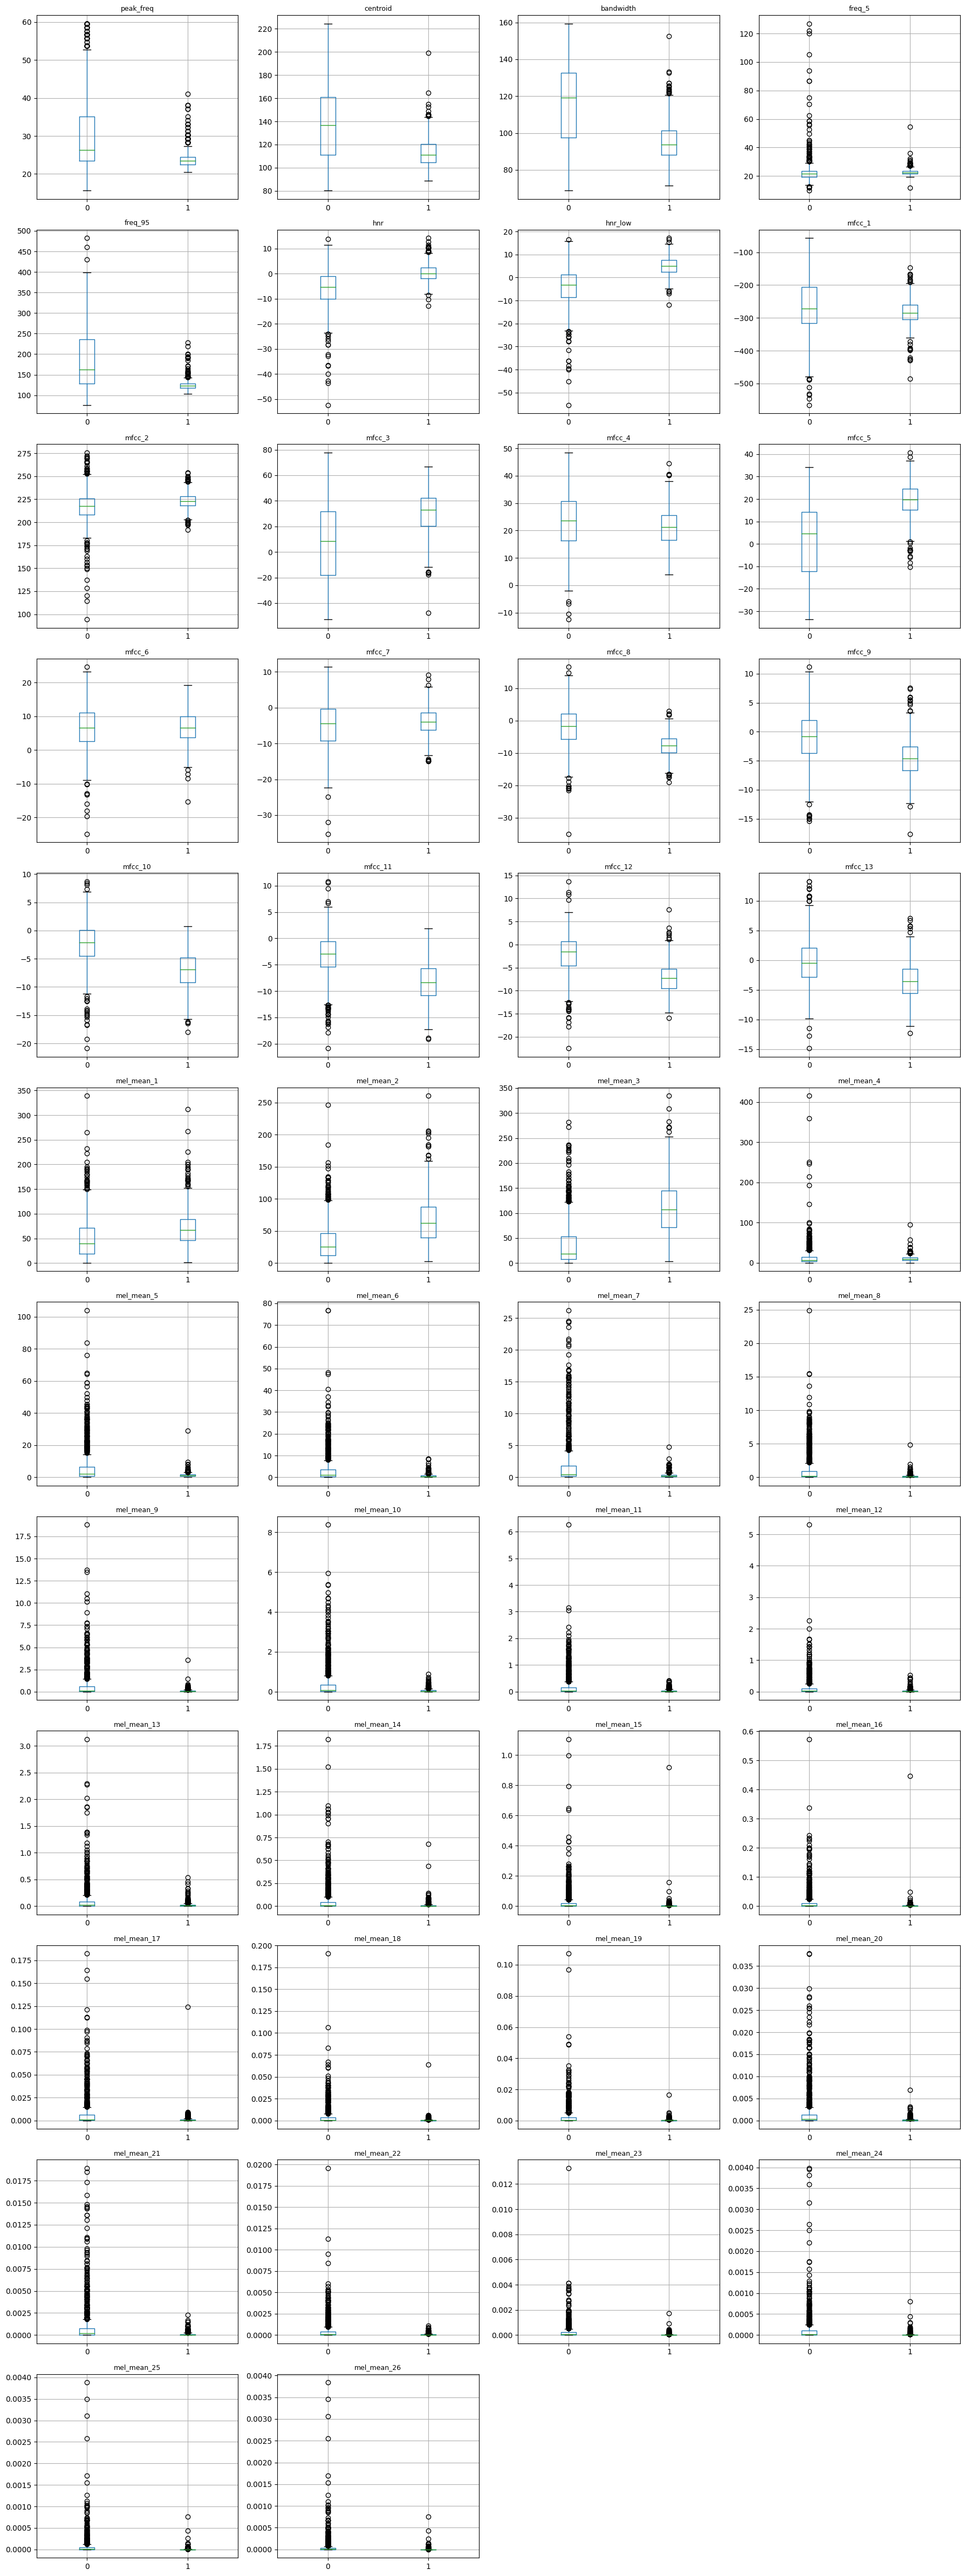

In [11]:
import matplotlib.pyplot as plt

# List of feature columns (everything except the label)
feature_cols = df.columns.drop("label")

# Determine the layout of the figure
n_features = len(feature_cols)
n_cols = 4
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(18, 4 * n_rows)
)

axes = axes.flatten()

for i, feature in enumerate(feature_cols):

    df.boxplot(
        column=feature,
        by="label",
        ax=axes[i]
    )

    axes[i].set_title(feature, fontsize=9)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("")

# Remove any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("")
plt.tight_layout()

plt.show()

### Statistical Testing
Because our data does not follow a uniform distribution, we will use a **Mann-Whitney U test**

In [12]:
from scipy.stats import mannwhitneyu

In [13]:
# run the test on every feature
results = []

feature_cols = df.columns.drop("label")

for feature in feature_cols:

    background = df[df["label"] == 0][feature]
    rumble = df[df["label"] == 1][feature]

    stat, p = mannwhitneyu(
        background,
        rumble,
        alternative="two-sided"
    )

    results.append({
        "Feature": feature,
        "U Statistic": stat,
        "P Value": p
    })

results = pd.DataFrame(results)

In [14]:
# rank the features
results = results.sort_values("P Value")

results.head(20)

,Feature,U Statistic,P Value
22,mel_mean_3,72167.0,6.049656e-124
11,mfcc_5,85149.0,3.582002e-108
6,hnr_low,85265.0,4.899570e-108
17,mfcc_11,445890.0,1.785576e-106
16,mfcc_10,442362.0,2.075546e-102
18,mfcc_12,441327.0,3.122786e-101
14,mfcc_8,431445.0,2.445304e-90
4,freq_95,429052.5,7.941162e-88
5,hnr,112319.0,1.110753e-78
21,mel_mean_2,113848.0,3.662573e-77


In [15]:
results["Significant"] = results["P Value"] < 0.05

results.head(20)

,Feature,U Statistic,P Value,Significant
22,mel_mean_3,72167.0,6.049656e-124,True
11,mfcc_5,85149.0,3.582002e-108,True
6,hnr_low,85265.0,4.899570e-108,True
17,mfcc_11,445890.0,1.785576e-106,True
16,mfcc_10,442362.0,2.075546e-102,True
18,mfcc_12,441327.0,3.122786e-101,True
14,mfcc_8,431445.0,2.445304e-90,True
4,freq_95,429052.5,7.941162e-88,True
5,hnr,112319.0,1.110753e-78,True
21,mel_mean_2,113848.0,3.662573e-77,True


In [16]:
results["Significant"].value_counts()

Significant
True     45
False     1
Name: count, dtype: int64

In [17]:
results[results["Significant"] == False]

,Feature,U Statistic,P Value,Significant
12,mfcc_6,259317.0,0.397944,False


To reduce the chance of luck in our analysis, we will use a **Benjamini–Hochberg false discovery rate (FDR)** to adjust the p-va;ues

In [18]:
from statsmodels.stats.multitest import multipletests

results["Adjusted P"] = multipletests(
    results["P Value"],
    method="fdr_bh"
)[1]

results["Significant (FDR)"] = results["Adjusted P"] < 0.05

### Logistic Regression

In [19]:
print(X_train.shape)
print(X_test.shape)

print(y_train.value_counts())
print(y_test.value_counts())

(1513, 46)
(379, 46)
label
0    956
1    557
Name: count, dtype: int64
label
0    231
1    148
Name: count, dtype: int64


In [20]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [21]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

model.fit(
    X_train_scaled,
    y_train
)

LogisticRegression(max_iter=1000, random_state=42)

In [22]:
y_pred = model.predict(X_test_scaled)

### Classifier Evaluation

In [23]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[196  35]
 [ 21 127]]


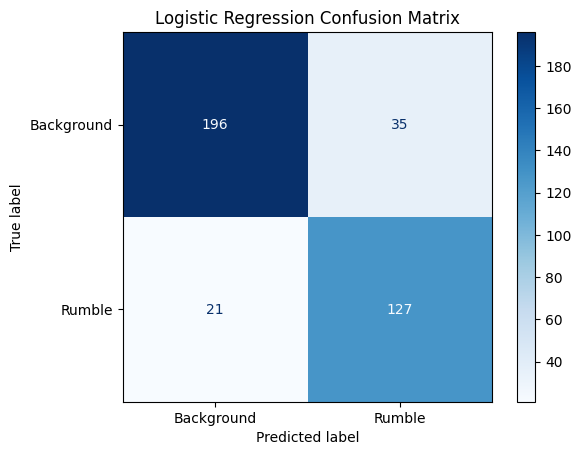

In [24]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["Background", "Rumble"],
    cmap="Blues"
)

plt.title("Logistic Regression Confusion Matrix")
plt.show()

In [25]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.90      0.85      0.88       231
           1       0.78      0.86      0.82       148

    accuracy                           0.85       379
   macro avg       0.84      0.85      0.85       379
weighted avg       0.86      0.85      0.85       379



In [26]:
from sklearn.metrics import roc_auc_score

y_prob = model.predict_proba(X_test_scaled)[:, 1]

auc = roc_auc_score(y_test, y_prob)

print(f"ROC-AUC: {auc:.3f}")

ROC-AUC: 0.913


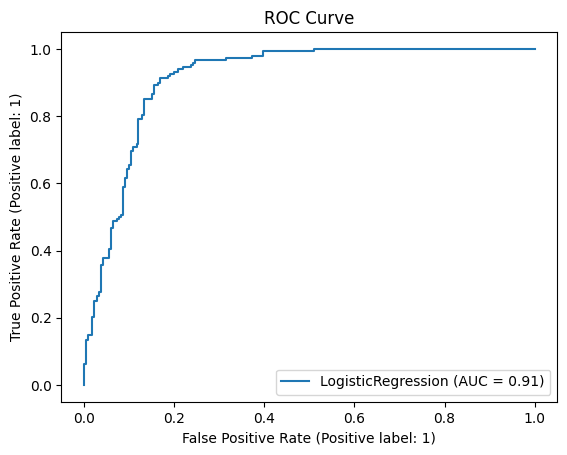

In [27]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(
    model,
    X_test_scaled,
    y_test
)

plt.title("ROC Curve")
plt.show()

### Feature Importance from Logistic Regression

In [28]:
import pandas as pd

coefficients = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": model.coef_[0]
})

coefficients["Absolute Coefficient"] = (
    coefficients["Coefficient"].abs()
)

coefficients = coefficients.sort_values(
    "Absolute Coefficient",
    ascending=False
)

coefficients.head(10)

,Feature,Coefficient,Absolute Coefficient
6,hnr_low,2.380265,2.380265
5,hnr,-2.004892,2.004892
4,freq_95,-1.143989,1.143989
24,mel_mean_5,-1.049885,1.049885
32,mel_mean_13,0.981490,0.981490
45,mel_mean_26,-0.873105,0.873105
0,peak_freq,-0.856912,0.856912
44,mel_mean_25,-0.814632,0.814632
9,mfcc_3,-0.720978,0.720978
23,mel_mean_4,-0.588678,0.588678


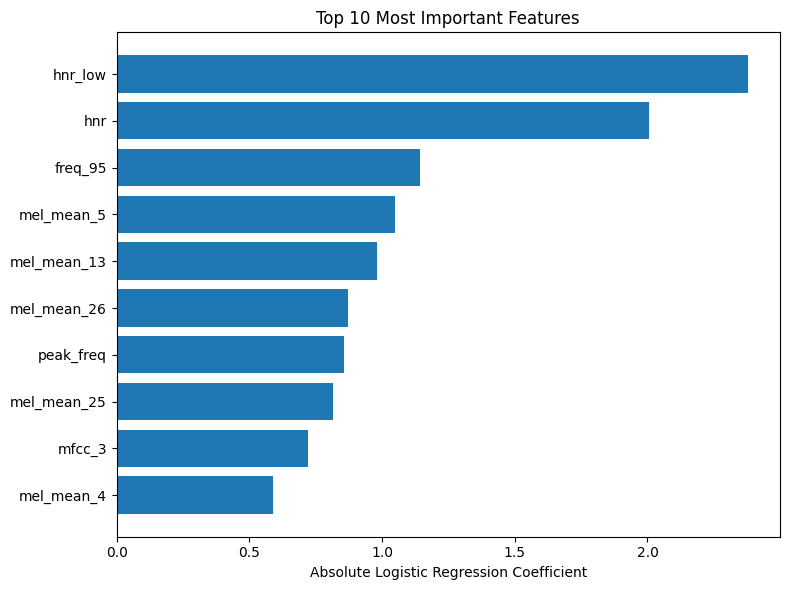

In [29]:
import matplotlib.pyplot as plt

top10 = coefficients.head(10)

plt.figure(figsize=(8,6))

plt.barh(
    top10["Feature"],
    top10["Absolute Coefficient"]
)

plt.xlabel("Absolute Logistic Regression Coefficient")
plt.title("Top 10 Most Important Features")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [30]:
feature_summary = coefficients.merge(
    results,
    on="Feature"
)

feature_summary = feature_summary.sort_values(
    "Absolute Coefficient",
    ascending=False
)

feature_summary.head(10)

,Feature,Coefficient,Absolute Coefficient,U Statistic,P Value,Significant,Adjusted P,Significant (FDR)
0,hnr_low,2.380265,2.380265,85265.0,4.899570e-108,True,7.512673e-107,True
1,hnr,-2.004892,2.004892,112319.0,1.110753e-78,True,5.677180e-78,True
2,freq_95,-1.143989,1.143989,429052.5,7.941162e-88,True,4.566168e-87,True
3,mel_mean_5,-1.049885,1.049885,368082.0,1.930171e-35,True,3.414918e-35,True
4,mel_mean_13,0.981490,0.981490,316596.0,8.107986e-10,True,9.096765e-10,True
5,mel_mean_26,-0.873105,0.873105,391811.0,5.685418e-53,True,1.634558e-52,True
6,peak_freq,-0.856912,0.856912,364780.0,9.386905e-34,True,1.542134e-33,True
7,mel_mean_25,-0.814632,0.814632,399937.0,8.288435e-60,True,2.932831e-59,True
8,mfcc_3,-0.720978,0.720978,144836.0,1.219122e-49,True,2.951559e-49,True
9,mel_mean_4,-0.588678,0.588678,224514.0,3.554751e-07,True,3.893298e-07,True


### Cross Validation with Random Forest

In [31]:
from sklearn.ensemble import RandomForestClassifier

In [32]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

In [33]:
rf_model.fit(
    X_train,
    y_train
)

RandomForestClassifier(n_estimators=200, random_state=42)

In [34]:
rf_pred = rf_model.predict(X_test)

In [35]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    rf_pred
))

              precision    recall  f1-score   support

           0       0.89      0.87      0.88       231
           1       0.80      0.83      0.81       148

    accuracy                           0.85       379
   macro avg       0.84      0.85      0.85       379
weighted avg       0.85      0.85      0.85       379



### RandomForest Feature Importance

In [36]:
import pandas as pd

rf_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
})

rf_importance = rf_importance.sort_values(
    "Importance",
    ascending=False
)

rf_importance.head(15)

,Feature,Importance
6,hnr_low,0.089244
22,mel_mean_3,0.079884
5,hnr,0.057685
4,freq_95,0.057559
18,mfcc_12,0.051466
14,mfcc_8,0.046762
11,mfcc_5,0.046507
17,mfcc_11,0.041404
16,mfcc_10,0.040325
2,bandwidth,0.030480


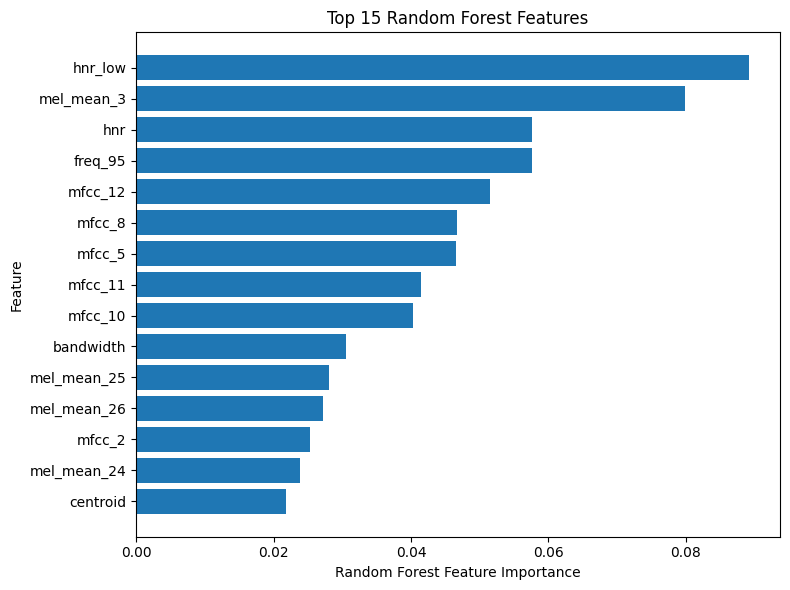

In [37]:
import matplotlib.pyplot as plt

top15 = rf_importance.head(15)

plt.figure(figsize=(8,6))

plt.barh(
    top15["Feature"],
    top15["Importance"]
)

plt.xlabel("Random Forest Feature Importance")
plt.ylabel("Feature")
plt.title("Top 15 Random Forest Features")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [38]:
# Mann-Whitney U ranking
mw_rank = results.copy()

mw_rank = mw_rank.sort_values("P Value")

mw_rank["MW Rank"] = range(1, len(mw_rank)+1)

mw_rank = mw_rank[[
    "Feature",
    "MW Rank",
    "P Value"
]]

# Logistic Regression ranking
lr_rank = coefficients.copy()

lr_rank = lr_rank.sort_values(
    "Absolute Coefficient",
    ascending=False
)

lr_rank["LR Rank"] = range(1, len(lr_rank)+1)

lr_rank = lr_rank[[
    "Feature",
    "Coefficient",
    "Absolute Coefficient",
    "LR Rank"
]]

# Random Forest ranking
rf_rank = rf_importance.copy()

rf_rank = rf_rank.sort_values(
    "Importance",
    ascending=False
)

rf_rank["RF Rank"] = range(1, len(rf_rank)+1)

rf_rank = rf_rank[[
    "Feature",
    "Importance",
    "RF Rank"
]]

# merge
comparison = (
    mw_rank
    .merge(lr_rank, on="Feature")
    .merge(rf_rank, on="Feature")
)

# add overall ranking
comparison["Average Rank"] = (
    comparison["MW Rank"] +
    comparison["LR Rank"] +
    comparison["RF Rank"]
) / 3
comparison = comparison.sort_values("Average Rank")
comparison = comparison[[
    "Feature",
    "P Value",
    "Coefficient",
    "Importance",
    "MW Rank",
    "LR Rank",
    "RF Rank",
    "Average Rank"
]]

comparison.head(20)

,Feature,P Value,Coefficient,Importance,MW Rank,LR Rank,RF Rank,Average Rank
2,hnr_low,4.899570e-108,2.380265,0.089244,3,1,1,1.666667
8,hnr,1.110753e-78,-2.004892,0.057685,9,2,3,4.666667
7,freq_95,7.941162e-88,-1.143989,0.057559,8,3,4,5.000000
0,mel_mean_3,6.049656e-124,0.315510,0.079884,1,20,2,7.666667
1,mfcc_5,3.582002e-108,0.432064,0.046507,2,16,7,8.333333
6,mfcc_8,2.445304e-90,-0.421925,0.046762,7,17,6,10.000000
12,mel_mean_25,8.288435e-60,-0.814632,0.028016,13,8,11,10.666667
10,bandwidth,1.661611e-73,-0.485470,0.030480,11,11,10,10.666667
4,mfcc_10,2.075546e-102,-0.377024,0.040325,5,19,9,11.000000
15,mel_mean_26,5.685418e-53,-0.873105,0.027202,16,6,12,11.333333
